In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pandas.plotting import autocorrelation_plot

In [2]:
dataset_path = "data_hourly final.csv"

df = pd.read_csv(dataset_path)
print("Device ID:", df["device_id"].unique())
df.head()


Device ID: ['USGC00']


,data_id,device_id,datetime,voltage,current,power,energy,frequency,pf,energy_hour
0,1,USGC00,2025-08-11 17:00:00,233.020,2.43758,543.043,55.654,50.0000,0.953167,0.352
1,2,USGC00,2025-08-11 18:00:00,234.557,2.54540,582.805,56.045,50.0000,0.973000,0.391
2,3,USGC00,2025-08-11 19:00:00,239.353,1.19923,250.752,56.445,50.0000,0.871667,0.400
3,4,USGC00,2025-08-11 20:00:00,240.775,1.03432,209.535,56.669,49.9883,0.840167,0.224
4,5,USGC00,2025-08-11 21:00:00,237.303,1.32697,283.777,56.894,50.0000,0.900667,0.225


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3762 entries, 0 to 3761
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   data_id      3762 non-null   int64  
 1   device_id    3762 non-null   object 
 2   datetime     3762 non-null   object 
 3   voltage      3762 non-null   float64
 4   current      3762 non-null   float64
 5   power        3762 non-null   float64
 6   energy       3762 non-null   float64
 7   frequency    3762 non-null   float64
 8   pf           3762 non-null   float64
 9   energy_hour  3762 non-null   float64
dtypes: float64(7), int64(1), object(2)
memory usage: 294.0+ KB


In [4]:
df.isna().sum()

data_id        0
device_id      0
datetime       0
voltage        0
current        0
power          0
energy         0
frequency      0
pf             0
energy_hour    0
dtype: int64

In [5]:
df.drop(columns=["data_id"], inplace=True)
df.drop(columns=["device_id"], inplace=True)
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime")
df = df.set_index("datetime")

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3762 entries, 2025-08-11 17:00:00 to 2026-01-16 14:00:00
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   voltage      3762 non-null   float64
 1   current      3762 non-null   float64
 2   power        3762 non-null   float64
 3   energy       3762 non-null   float64
 4   frequency    3762 non-null   float64
 5   pf           3762 non-null   float64
 6   energy_hour  3762 non-null   float64
dtypes: float64(7)
memory usage: 235.1 KB


In [6]:
df.index = df.index.floor('H')

print("Jumlah data duplikat:", df.index.duplicated().sum())
df[df.index.duplicated(keep=False)]

Jumlah data duplikat: 2


C:\Users\hakimfrh\AppData\Local\Temp\ipykernel_2912\287894102.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df.index = df.index.floor('H')


,voltage,current,power,energy,frequency,pf,energy_hour
datetime,,,,,,,
2025-08-24 08:00:00,237.762,0.717983,162.718,111.848,50.0000,0.950000,0.121
2025-08-24 08:00:00,238.469,0.547775,118.228,111.968,49.9941,0.886921,0.121
2025-08-24 11:00:00,238.098,0.726850,162.930,112.288,50.0000,0.936333,0.173
2025-08-24 11:00:00,238.150,0.595139,129.571,112.419,49.9842,0.901140,0.173


In [7]:
df = df[~df.index.duplicated()]
print("Jumlah data duplikat:", df.index.duplicated().sum())
df[df.index.duplicated(keep=False)]

Jumlah data duplikat: 0


,voltage,current,power,energy,frequency,pf,energy_hour
datetime,,,,,,,


array([<Axes: xlabel='datetime'>, <Axes: xlabel='datetime'>,
       <Axes: xlabel='datetime'>, <Axes: xlabel='datetime'>,
       <Axes: xlabel='datetime'>, <Axes: xlabel='datetime'>,
       <Axes: xlabel='datetime'>], dtype=object)

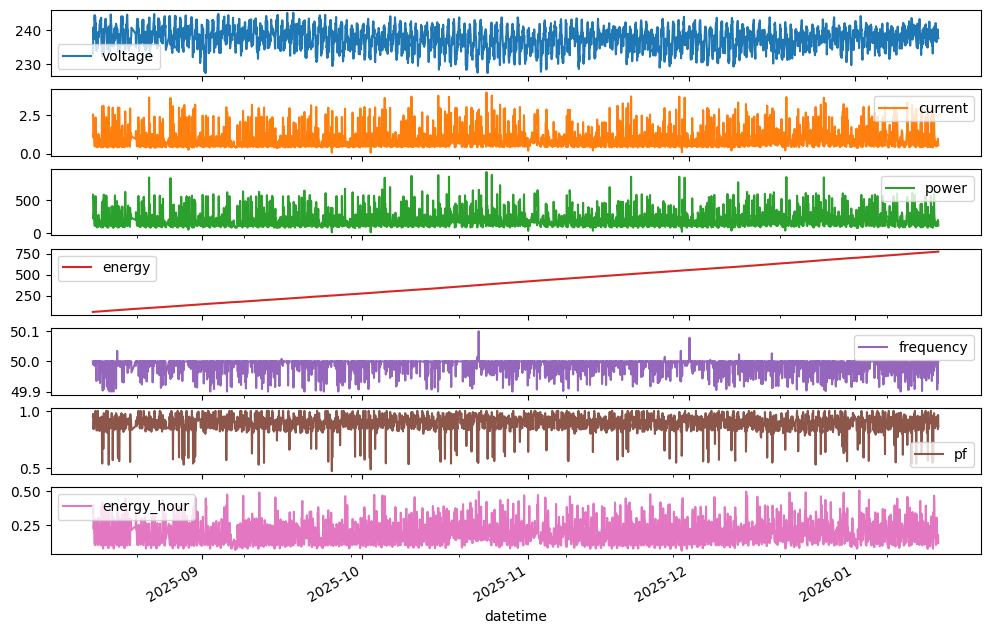

In [8]:
df.plot(subplots=True, figsize=(12,8))

In [9]:
df.drop(columns=["voltage"], inplace=True)
df.drop(columns=["current"], inplace=True)
df.drop(columns=["power"], inplace=True)
df.drop(columns=["energy"], inplace=True)
df.drop(columns=["frequency"], inplace=True)
df.drop(columns=["pf"], inplace=True)

In [10]:
df = df[df["energy_hour"] >= 0]

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3760 entries, 2025-08-11 17:00:00 to 2026-01-16 14:00:00
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   energy_hour  3760 non-null   float64
dtypes: float64(1)
memory usage: 187.8 KB


array([<Axes: xlabel='datetime'>], dtype=object)

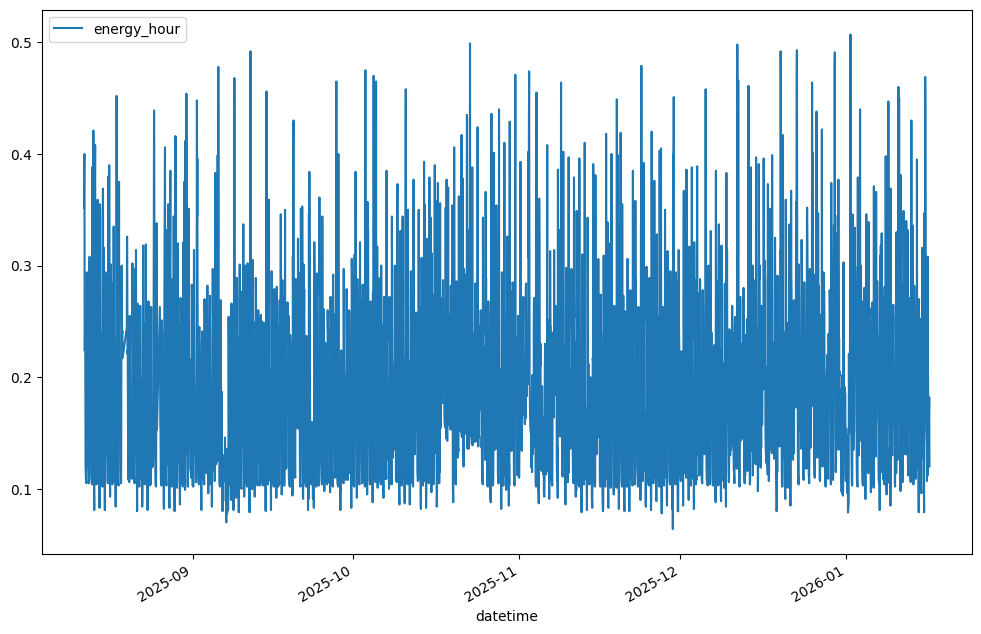

In [11]:
df.info()
df.plot(subplots=True, figsize=(12,8))

In [12]:
full_range = pd.date_range(start=df.index.min(),
                           end=df.index.max(),
                           freq="H")

missing_time = full_range.difference(df.index)
print("Jumlah jam hilang:", len(missing_time))
print(missing_time)

Jumlah jam hilang: 30
DatetimeIndex(['2025-08-18 23:00:00', '2025-08-19 00:00:00',
               '2025-08-19 01:00:00', '2025-08-19 02:00:00',
               '2025-08-19 03:00:00', '2025-08-19 04:00:00',
               '2025-08-19 05:00:00', '2025-08-19 06:00:00',
               '2025-08-19 07:00:00', '2025-08-19 08:00:00',
               '2025-08-19 09:00:00', '2025-08-19 10:00:00',
               '2025-08-19 11:00:00', '2025-08-19 12:00:00',
               '2025-08-19 13:00:00', '2025-08-19 14:00:00',
               '2025-08-19 15:00:00', '2025-08-19 16:00:00',
               '2025-08-25 09:00:00', '2025-08-25 10:00:00',
               '2025-08-25 11:00:00', '2025-08-25 12:00:00',
               '2025-08-25 13:00:00', '2025-08-25 14:00:00',
               '2025-08-25 15:00:00', '2025-08-25 16:00:00',
               '2025-08-25 17:00:00', '2025-08-25 18:00:00',
               '2025-08-25 19:00:00', '2025-08-25 20:00:00'],
              dtype='datetime64[ns]', freq=None)


C:\Users\hakimfrh\AppData\Local\Temp\ipykernel_2912\3867691930.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_range = pd.date_range(start=df.index.min(),


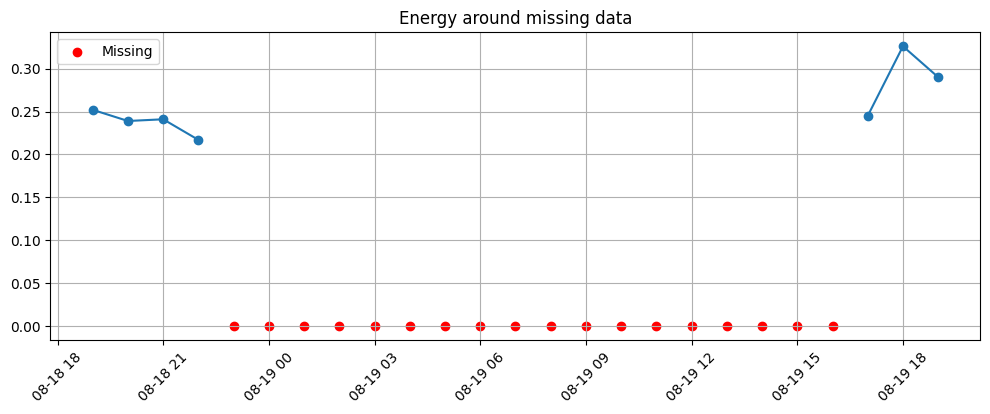

In [13]:
start = "2025-08-18 19:00:00"
end   = "2025-08-19 19:00:00"

full_range = pd.date_range(start=start, end=end, freq="h")
df_zoom = df.reindex(full_range)
df_zoom.head(10)
import matplotlib.pyplot as plt



plt.figure(figsize=(12,4))
plt.plot(df_zoom.index, df_zoom["energy_hour"], marker="o")
plt.scatter(df_zoom.index[df_zoom["energy_hour"].isna()],
            [0]*df_zoom["energy_hour"].isna().sum(),
            color="red", label="Missing")
plt.legend()
plt.title("Energy around missing data")
plt.xticks(rotation=45)
plt.grid()
plt.show()


In [14]:
# def smart_fill(df, col, data_limit=2):
#     df = df.copy()

#     for t in df[df[col].isna()].index:
#         values = []

#         # 1. Tetangga jam dekat
#         for h in [-1, 1]:
#             if t + pd.Timedelta(hours=h) in df.index:
#                 val = df.loc[t + pd.Timedelta(hours=h), col]
#                 if not pd.isna(val):
#                     values.append(val)

#         # 2. Hari sebelum & sesudah
#         for d in [-1, 1]:
#             time_check = t + pd.Timedelta(days=d)
#             if time_check in df.index:
#                 val = df.loc[time_check, col]
#                 if not pd.isna(val):
#                     values.append(val)

#         # 3. Minggu sekitar (sesuai data_limit)
#         for w in range(1, data_limit+1):
#             for sign in [-1, 1]:
#                 time_check = t + pd.Timedelta(weeks=w*sign)
#                 if time_check in df.index:
#                     val = df.loc[time_check, col]
#                     if not pd.isna(val):
#                         values.append(val)

#         # Isi pakai median
#         if values:
#             df.loc[t, col] = np.median(values)

#     return df


def smart_fill(df, col, data_limit=2, verbose=True):
    df = df.copy()

    missing_times = df[df[col].isna()].index
    print(f"\nTotal missing value di kolom '{col}':", len(missing_times))

    for t in missing_times:
        values = []
        if verbose:
            print("\n==============================")
            print(f"Isi nilai untuk waktu: {t}")

        # 1️⃣ Tetangga jam dekat
        for h in [-1, 1]:
            check_time = t + pd.Timedelta(hours=h)
            if check_time in df.index:
                val = df.loc[check_time, col]
                if not pd.isna(val):
                    values.append(val)
                    if verbose:
                        print(f"  ✔ Tetangga jam ({h:+}h): {check_time} → {val}")
                else:
                    if verbose:
                        print(f"  ✖ Tetangga jam ({h:+}h): {check_time} ada tapi NaN")
            else:
                if verbose:
                    print(f"  - Tetangga jam ({h:+}h): {check_time} tidak ada di index")

        # 2️⃣ Hari sebelum & sesudah
        for d in [-1, 1]:
            check_time = t + pd.Timedelta(days=d)
            if check_time in df.index:
                val = df.loc[check_time, col]
                if not pd.isna(val):
                    values.append(val)
                    if verbose:
                        print(f"  ✔ Hari ({d:+}d): {check_time} → {val}")
                else:
                    if verbose:
                        print(f"  ✖ Hari ({d:+}d): {check_time} ada tapi NaN")
            else:
                if verbose:
                    print(f"  - Hari ({d:+}d): {check_time} tidak ada")

        # 3️⃣ Minggu sekitar
        for w in range(1, data_limit+1):
            for sign in [-1, 1]:
                check_time = t + pd.Timedelta(weeks=w*sign)
                if check_time in df.index:
                    val = df.loc[check_time, col]
                    if not pd.isna(val):
                        values.append(val)
                        if verbose:
                            print(f"  ✔ Minggu ({sign*w:+}w): {check_time} → {val}")
                    else:
                        if verbose:
                            print(f"  ✖ Minggu ({sign*w:+}w): {check_time} ada tapi NaN")
                else:
                    if verbose:
                        print(f"  - Minggu ({sign*w:+}w): {check_time} tidak ada")

        # 🔵 Hasil keputusan
        if values:
            new_val = np.median(values)
            df.loc[t, col] = new_val
            if verbose:
                print(f"  Nilai dipakai (median dari {len(values)} data): {new_val}")
        else:
            if verbose:
                print("  ⚠ Tidak ada referensi data. Tetap NaN.")

    return df



In [15]:

full_range = pd.date_range(df.index.min(), df.index.max(), freq="h")
df = df.reindex(full_range)
df = smart_fill(df, "energy_hour", data_limit=6)


Total missing value di kolom 'energy_hour': 30

Isi nilai untuk waktu: 2025-08-18 23:00:00
  ✔ Tetangga jam (-1h): 2025-08-18 22:00:00 → 0.217
  ✖ Tetangga jam (+1h): 2025-08-19 00:00:00 ada tapi NaN
  ✔ Hari (-1d): 2025-08-17 23:00:00 → 0.145
  ✔ Hari (+1d): 2025-08-19 23:00:00 → 0.116
  ✔ Minggu (-1w): 2025-08-11 23:00:00 → 0.205
  ✔ Minggu (+1w): 2025-08-25 23:00:00 → 0.156
  - Minggu (-2w): 2025-08-04 23:00:00 tidak ada
  ✔ Minggu (+2w): 2025-09-01 23:00:00 → 0.165
  - Minggu (-3w): 2025-07-28 23:00:00 tidak ada
  ✔ Minggu (+3w): 2025-09-08 23:00:00 → 0.179
  - Minggu (-4w): 2025-07-21 23:00:00 tidak ada
  ✔ Minggu (+4w): 2025-09-15 23:00:00 → 0.156
  - Minggu (-5w): 2025-07-14 23:00:00 tidak ada
  ✔ Minggu (+5w): 2025-09-22 23:00:00 → 0.151
  - Minggu (-6w): 2025-07-07 23:00:00 tidak ada
  ✔ Minggu (+6w): 2025-09-29 23:00:00 → 0.112
  Nilai dipakai (median dari 10 data): 0.156

Isi nilai untuk waktu: 2025-08-19 00:00:00
  ✔ Tetangga jam (-1h): 2025-08-18 23:00:00 → 0.156
  ✖ Teta

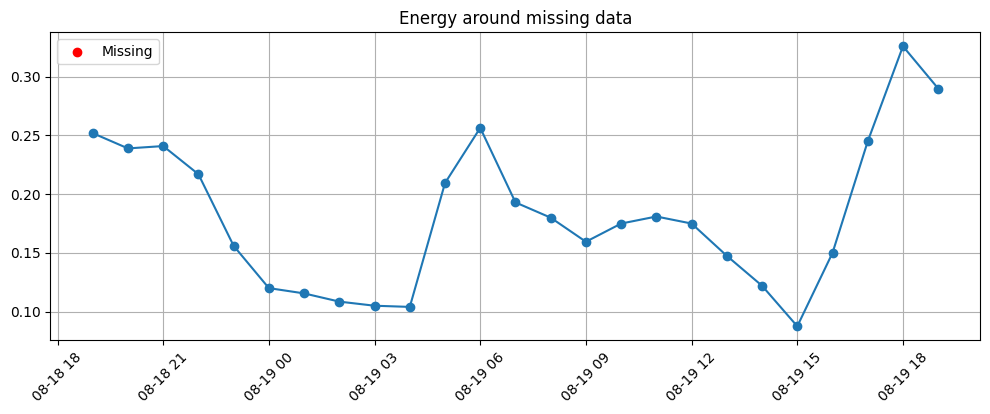

In [16]:
start = "2025-08-18 19:00:00"
end   = "2025-08-19 19:00:00"

full_range = pd.date_range(start=start, end=end, freq="h")
df_zoom = df.reindex(full_range)
df_zoom.head(10)
import matplotlib.pyplot as plt



plt.figure(figsize=(12,4))
plt.plot(df_zoom.index, df_zoom["energy_hour"], marker="o")
plt.scatter(df_zoom.index[df_zoom["energy_hour"].isna()],
            [0]*df_zoom["energy_hour"].isna().sum(),
            color="red", label="Missing")
plt.legend()
plt.title("Energy around missing data")
plt.xticks(rotation=45)
plt.grid()
plt.show()


In [17]:
df = df.sort_index()
df = df.asfreq('h')
full_range = pd.date_range(start=df.index.min(),
                           end=df.index.max(),
                           freq="H")

missing_time = full_range.difference(df.index)
print("Jumlah jam hilang:", len(missing_time))
print(missing_time)

Jumlah jam hilang: 0
DatetimeIndex([], dtype='datetime64[ns]', freq='h')


C:\Users\hakimfrh\AppData\Local\Temp\ipykernel_2912\1531309851.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_range = pd.date_range(start=df.index.min(),


In [18]:
count_per_day = df.resample('D').count()
full_days = count_per_day[count_per_day['energy_hour'] == 24].index
df_daily = df[df.index.floor('D').isin(full_days)]
df_daily = df_daily.resample('D').sum()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 157 entries, 2025-08-12 to 2026-01-15
Freq: D
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   energy_hour  157 non-null    float64
dtypes: float64(1)
memory usage: 2.5 KB


array([<Axes: >], dtype=object)

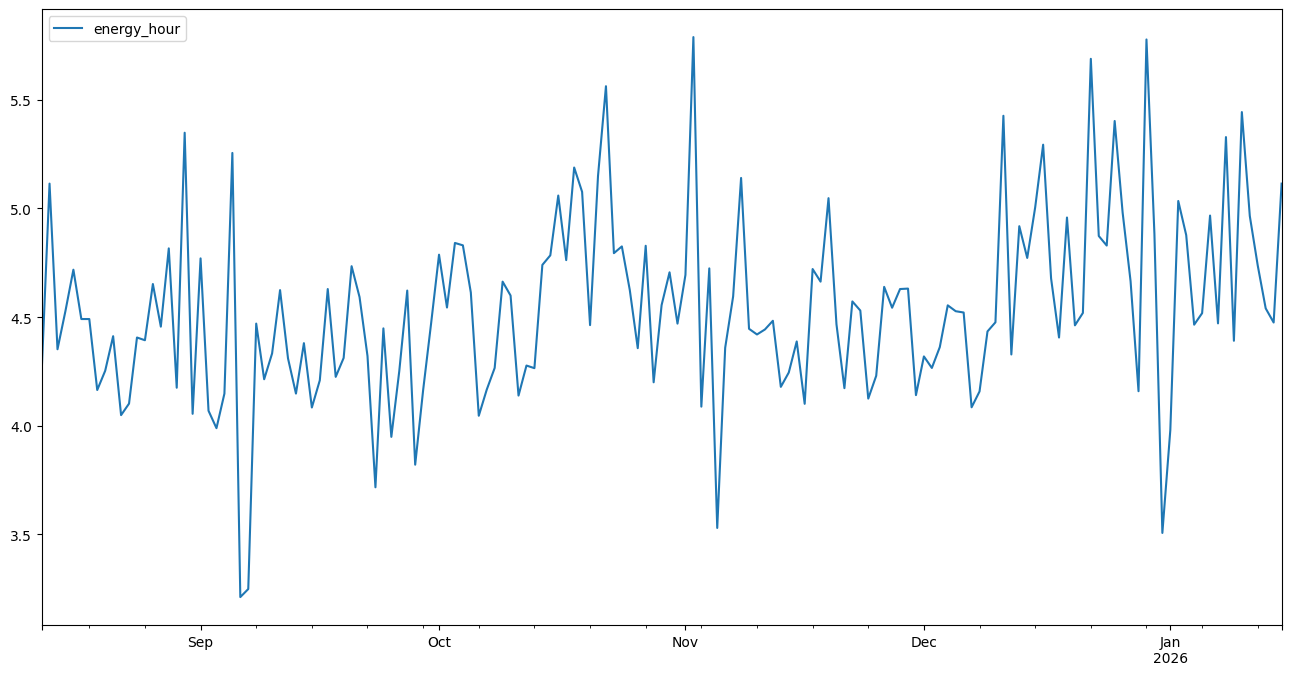

In [19]:
df_daily.info()
df_daily.plot(subplots=True, figsize=(16,8))

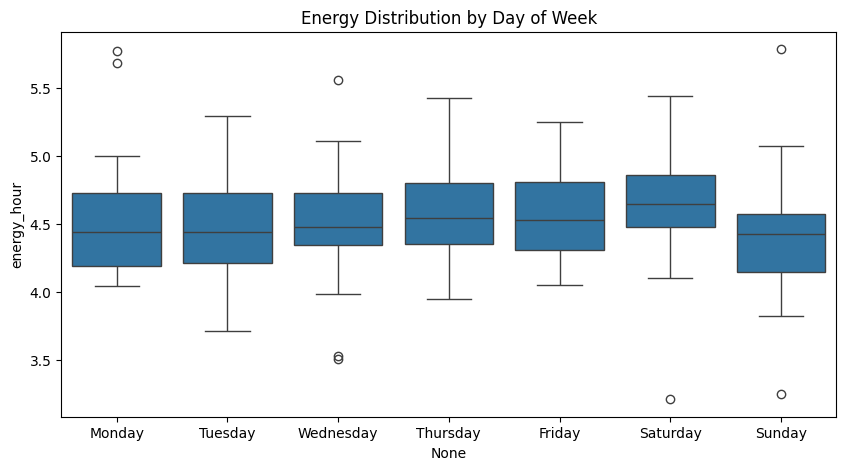

In [20]:
plt.figure(figsize=(10,5))
sns.boxplot(
    x=df_daily.index.day_name(),
    y=df_daily['energy_hour'],
    order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)
plt.title('Energy Distribution by Day of Week')
plt.show()


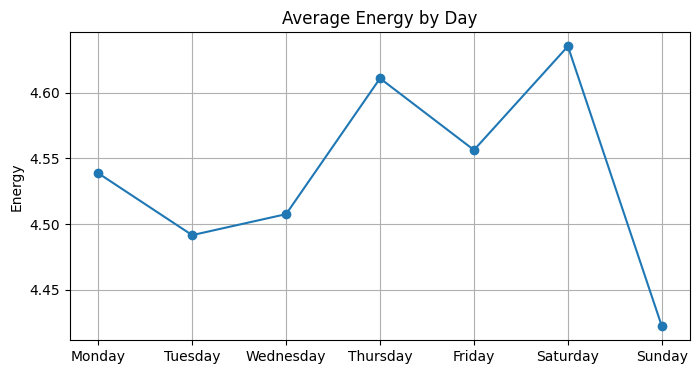

In [21]:
day_avg = df_daily.groupby(df_daily.index.day_name())['energy_hour'].mean()
day_avg = day_avg.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

plt.figure(figsize=(8,4))
plt.plot(day_avg.index, day_avg.values, marker='o')
plt.title('Average Energy by Day')
plt.ylabel('Energy')
plt.grid(True)
plt.show()


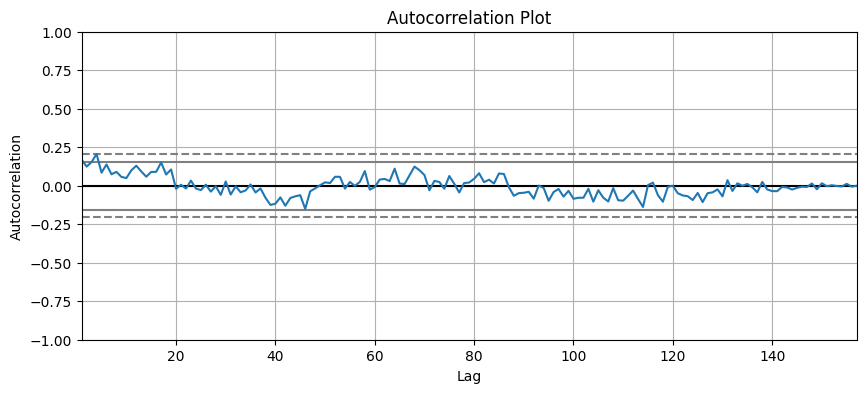

    lag  autocorr
3     4  0.209251
0     1  0.170206
16   17  0.167619
2     3  0.155434
5     6  0.142480
11   12  0.139313
1     2  0.125746
18   19  0.123571
10   11  0.106564
15   16  0.100245


In [22]:
plt.figure(figsize=(10,4))
autocorrelation_plot(df_daily['energy_hour'])
plt.title('Autocorrelation Plot')
plt.show()

max_lag = 30
lags = np.arange(1, max_lag + 1)
acf_vals = [df_daily['energy_hour'].autocorr(lag=i) for i in lags]
acf_df = pd.DataFrame({
    'lag': lags,
    'autocorr': acf_vals
})
top10 = acf_df.reindex(acf_df['autocorr'].abs().sort_values(ascending=False).index).head(10)
print(top10)

In [23]:
df_daily['dayofweek'] = df_daily.index.dayofweek  # 0-6

df_daily['dow_sin'] = np.sin(2 * np.pi * df_daily['dayofweek'] / 7)
df_daily['dow_cos'] = np.cos(2 * np.pi * df_daily['dayofweek'] / 7)

df_daily['dayofyear'] = df_daily.index.dayofyear  # 1-365

df_daily['doy_sin'] = np.sin(2 * np.pi * df_daily['dayofyear'] / 365)
df_daily['doy_cos'] = np.cos(2 * np.pi * df_daily['dayofyear'] / 365)

# df_daily['lag4'] = df_daily['energy_hour'].shift(4)
df_daily['lag7'] = df_daily['energy_hour'].shift(7)
df_daily = df_daily.dropna()

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >], dtype=object)

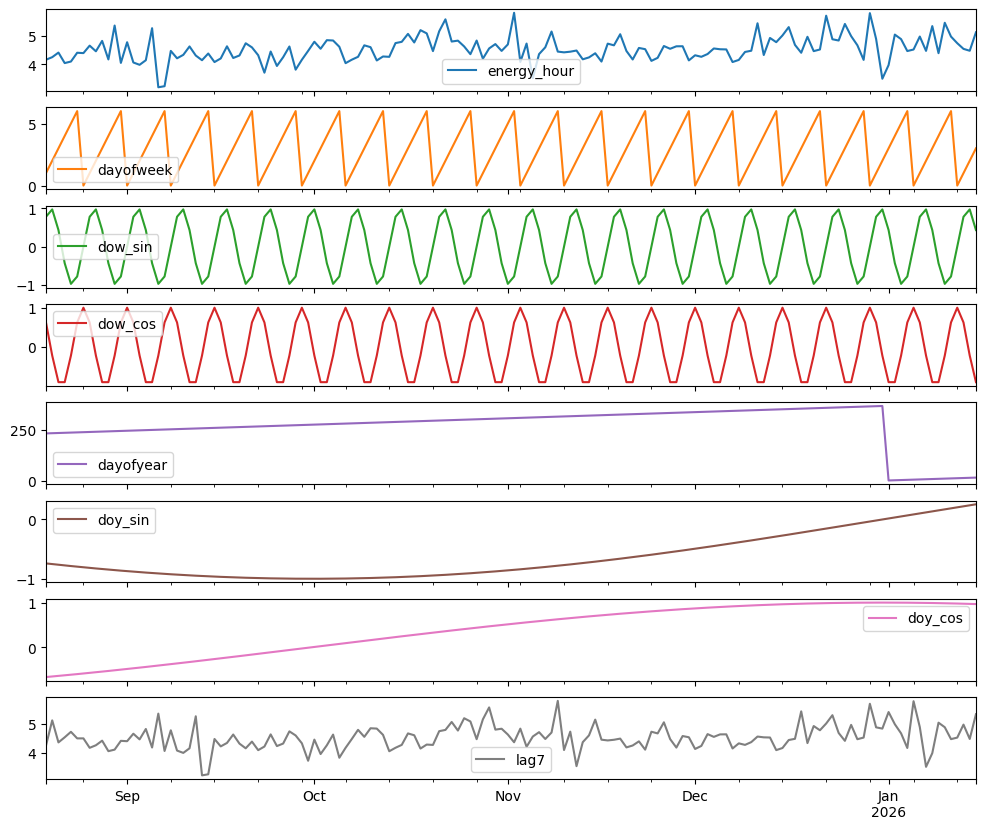

In [24]:
df_daily.plot(subplots=True, figsize=(12,10))

In [25]:
split_index = int(len(df_daily) * 0.8)

scaler = MinMaxScaler()
scaler.fit(df_daily.iloc[:split_index])
df_scaled = scaler.transform(df_daily)

print(f"total train: {len(df_scaled[:split_index])}")
print(f"total test: {len(df_scaled[split_index:])}")

total train: 120
total test: 30


In [26]:
def create_dataset(data, window=3, forecast=14):
    X, y, idx = [], [], []
    for i in range(len(data) - window - forecast + 1):
        X.append(data[i:i+window, :])
        y.append(data[i+window:i+window+forecast, 0])
        idx.append(i + window)
    return np.array(X), np.array(y), np.array(idx)

window_size = 3
forecast_size = 14
X, y, y_idx = create_dataset(df_scaled, window_size, forecast_size)

print(X.shape)  # (samples, window, features)
print(y.shape)  # (samples, forecast)

(134, 3, 8)
(134, 14)


In [27]:
train_mask = y_idx < split_index

X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

In [28]:
model = Sequential([
    LSTM(64, input_shape=(window_size, X.shape[2])),
    Dropout(0.1),
    Dense(32, activation='relu'),
    Dense(forecast_size)
])

C:\Users\hakimfrh\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [29]:
model.compile(optimizer=Adam(learning_rate=0.001), loss=Huber())
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           462 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,230 (82.93 KB)

 Trainable params: 21,230 (82.93 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
early_stop = EarlyStopping(patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(factor=0.5, patience=6, min_lr=1e-5)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=200,
    batch_size=16,
    callbacks=[early_stop, reduce_lr]
 )

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 0.1414 - val_loss: 0.1641 - learning_rate: 0.0010
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1023 - val_loss: 0.1158 - learning_rate: 0.0010
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0723 - val_loss: 0.0745 - learning_rate: 0.0010
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0453 - val_loss: 0.0523 - learning_rate: 0.0010
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0287 - val_loss: 0.0420 - learning_rate: 0.0010
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0207 - val_loss: 0.0312 - learning_rate: 0.0010
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0165 - val_loss: 0.0267 - learning_rate: 0.0010
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0152 - val_loss: 0.0250 - learning_rate: 0.0010
Epoch 9/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0142 - val_loss: 0.0248 - learning_rate: 0.0010
Epoch 10/200
8/8 ━━━━━━━━━━━

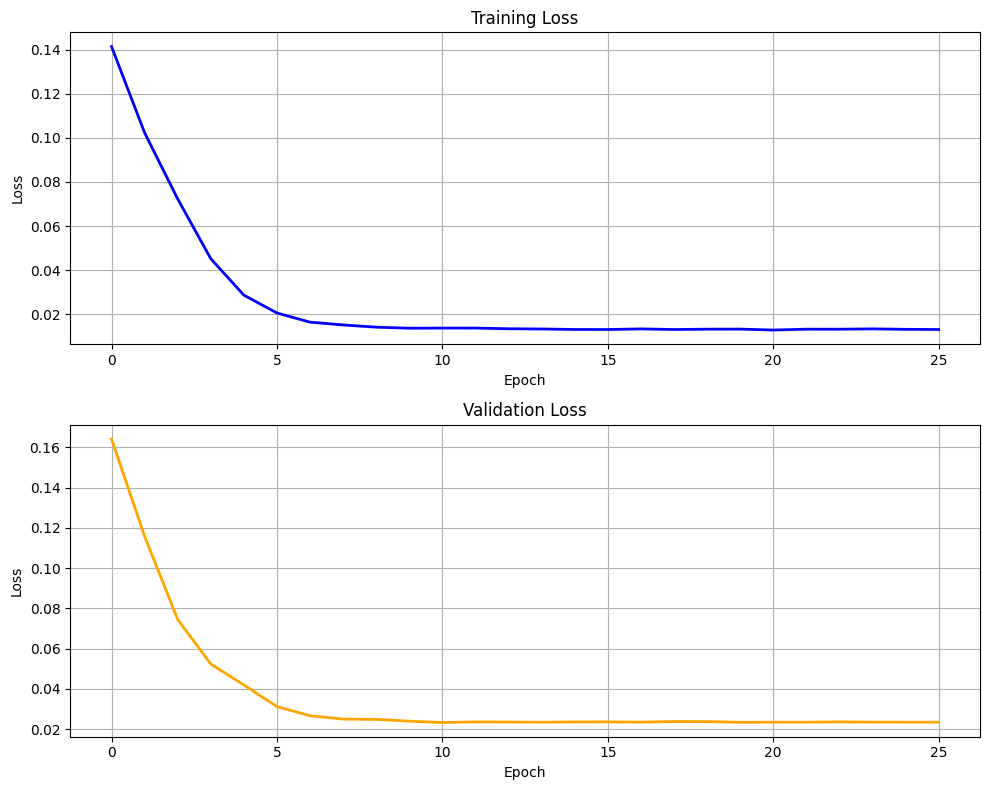

In [31]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Grafik atas: Training Loss
ax1.plot(history.history['loss'], color='blue', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.grid(True)

# Grafik bawah: Validation Loss
ax2.plot(history.history['val_loss'], color='orange', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Validation Loss')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [32]:
pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step


In [33]:
# inverse transform pred (samples, forecast)
n_samples, horizon = pred.shape
dummy = np.zeros((n_samples * horizon, df_scaled.shape[1]))
dummy[:, 0] = pred.reshape(-1)
pred_real = scaler.inverse_transform(dummy)[:, 0].reshape(n_samples, horizon)

In [34]:
# inverse transform y_test (samples, forecast)
n_samples, horizon = y_test.shape
dummy2 = np.zeros((n_samples * horizon, df_scaled.shape[1]))
dummy2[:, 0] = y_test.reshape(-1)
y_real = scaler.inverse_transform(dummy2)[:, 0].reshape(n_samples, horizon)

RMSE: 0.5556794410904161
MAPE: 9.486076964925319 %
MAE: 0.4282571087725023


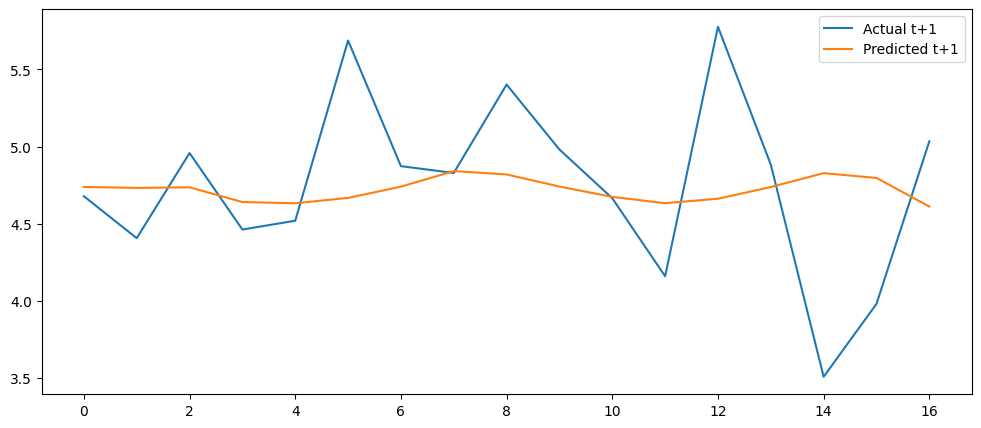

In [35]:
rmse = np.sqrt(mean_squared_error(y_real.reshape(-1), pred_real.reshape(-1)))
mape = np.mean(np.abs((y_real.reshape(-1) - pred_real.reshape(-1)) / np.clip(y_real.reshape(-1), 1e-6, None))) * 100
mae = mean_absolute_error(y_real.reshape(-1), pred_real.reshape(-1))
print("RMSE:", rmse)
print("MAPE:", mape, "%")
print("MAE:", mae)

# Plot horizon 1 (t+1) untuk contoh
plt.figure(figsize=(12,5))
plt.plot(y_real[:, 0], label="Actual t+1")
plt.plot(pred_real[:, 0], label="Predicted t+1")
plt.legend()
plt.show()

In [36]:
# Forecast 7 hari diganti: model sekarang direct 14-step
print("Gunakan cell prediksi 14 hari (direct multi-step).")

Gunakan cell prediksi 14 hari (direct multi-step).


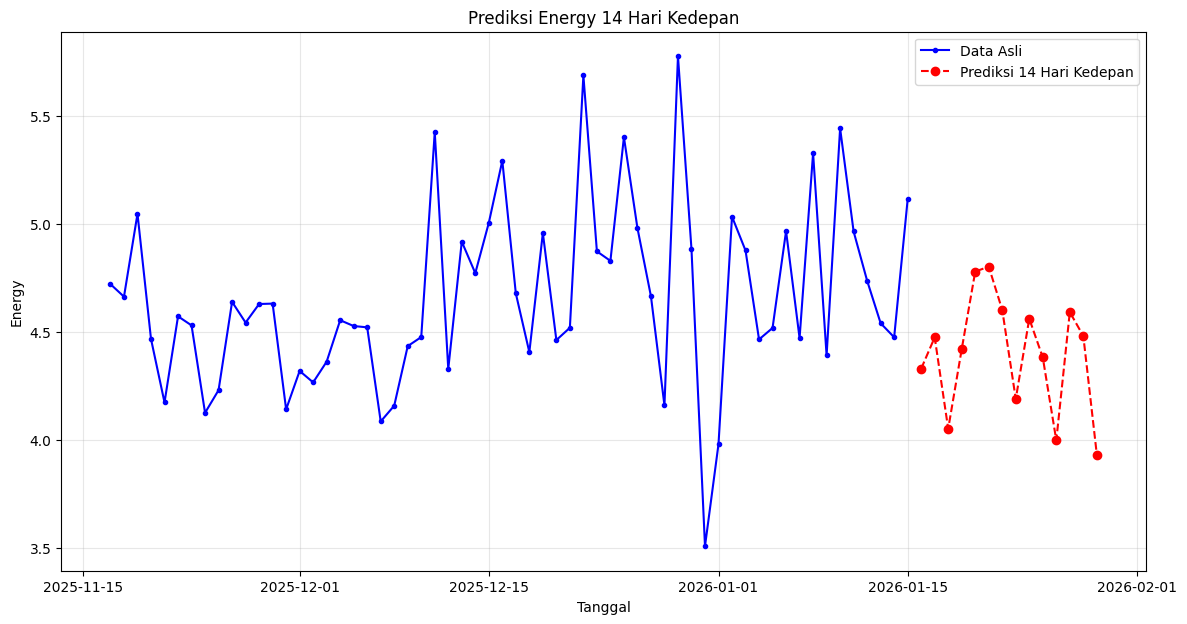

      Tanggal  Prediksi Energy
0  2026-01-16         4.329450
1  2026-01-17         4.474574
2  2026-01-18         4.050947
3  2026-01-19         4.419732
4  2026-01-20         4.779387
5  2026-01-21         4.802147
6  2026-01-22         4.601481
7  2026-01-23         4.189210
8  2026-01-24         4.560977
9  2026-01-25         4.381468
10 2026-01-26         3.997338
11 2026-01-27         4.591501
12 2026-01-28         4.480680
13 2026-01-29         3.931054


In [37]:
# Prediksi langsung 14 hari ke depan (direct multi-step)
last_sequence = df_scaled[-window_size:]
current_seq = last_sequence.reshape(1, window_size, df_scaled.shape[1])

pred = model.predict(current_seq, verbose=0)
pred_scaled = pred[0]  # (14,)

dummy_pred = np.zeros((forecast_size, df_scaled.shape[1]))
dummy_pred[:, 0] = pred_scaled
real_predictions = scaler.inverse_transform(dummy_pred)[:, 0]

last_date = df_daily.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_size)

plt.figure(figsize=(14, 7))
plot_days = 60
plt.plot(df_daily.index[-plot_days:], df_daily['energy_hour'][-plot_days:],
         color='blue', label='Data Asli', marker='.', linestyle='-')
plt.plot(future_dates, real_predictions,
         color='red', label='Prediksi 14 Hari Kedepan', marker='o', linestyle='--')

plt.title('Prediksi Energy 14 Hari Kedepan')
plt.xlabel('Tanggal')
plt.ylabel('Energy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

result_df = pd.DataFrame({
    'Tanggal': future_dates,
    'Prediksi Energy': real_predictions
})
print(result_df)

In [38]:
# Model save name (without extension)
model_name = "siwatt_lstm_day_v1.3"

model.save(f"{model_name}.keras")
print(f"Saved model to {model_name}.keras")


Saved model to siwatt_lstm_day_v1.3.keras
